In [2]:
import pandas as pd
import numpy as np
from tqdm.contrib.itertools import product
from pathlib import Path

bids_folder = Path('/data/ds-neuralpriors')

In [4]:
subjects = list(range(1, 42))
subjects.remove(23)

model_labels =[15, 18]
fit_responses = [False]

smoothed = True

fisher_information = []
keys = [] 

for subject, model_label, fit_response in product(subjects, model_labels, fit_responses):

        # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if fit_response:
        key += '.fit_responses'

    target_dir = Path(bids_folder) / 'derivatives' / 'fisher_information2' / key / f'sub-{subject:02d}' / 'func'

    try:
        fi = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-fisher_information.tsv', sep='\t')
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, model {model_label}, fit_response {fit_response}: {e}')
    
        continue

    fisher_information.append(fi)
    keys.append((subject , model_label, fit_response, smoothed))

# Concatenate all dataframes
fisher_information = pd.concat(fisher_information, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed'])

  0%|          | 0/80 [00:00<?, ?it/s]

File not found for subject 1, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/fisher_information2/model18.smoothed/sub-01/func/sub-01_desc-fisher_information.tsv'
File not found for subject 2, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/fisher_information2/model18.smoothed/sub-02/func/sub-02_desc-fisher_information.tsv'
File not found for subject 3, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/fisher_information2/model18.smoothed/sub-03/func/sub-03_desc-fisher_information.tsv'
File not found for subject 4, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/fisher_information2/model18.smoothed/sub-04/func/sub-04_desc-fisher_information.tsv'
File not found for subject 5, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/

Text(0.5, 1.05, 'Fisher information (model 15, smoothed, fitted on ground-truth)')

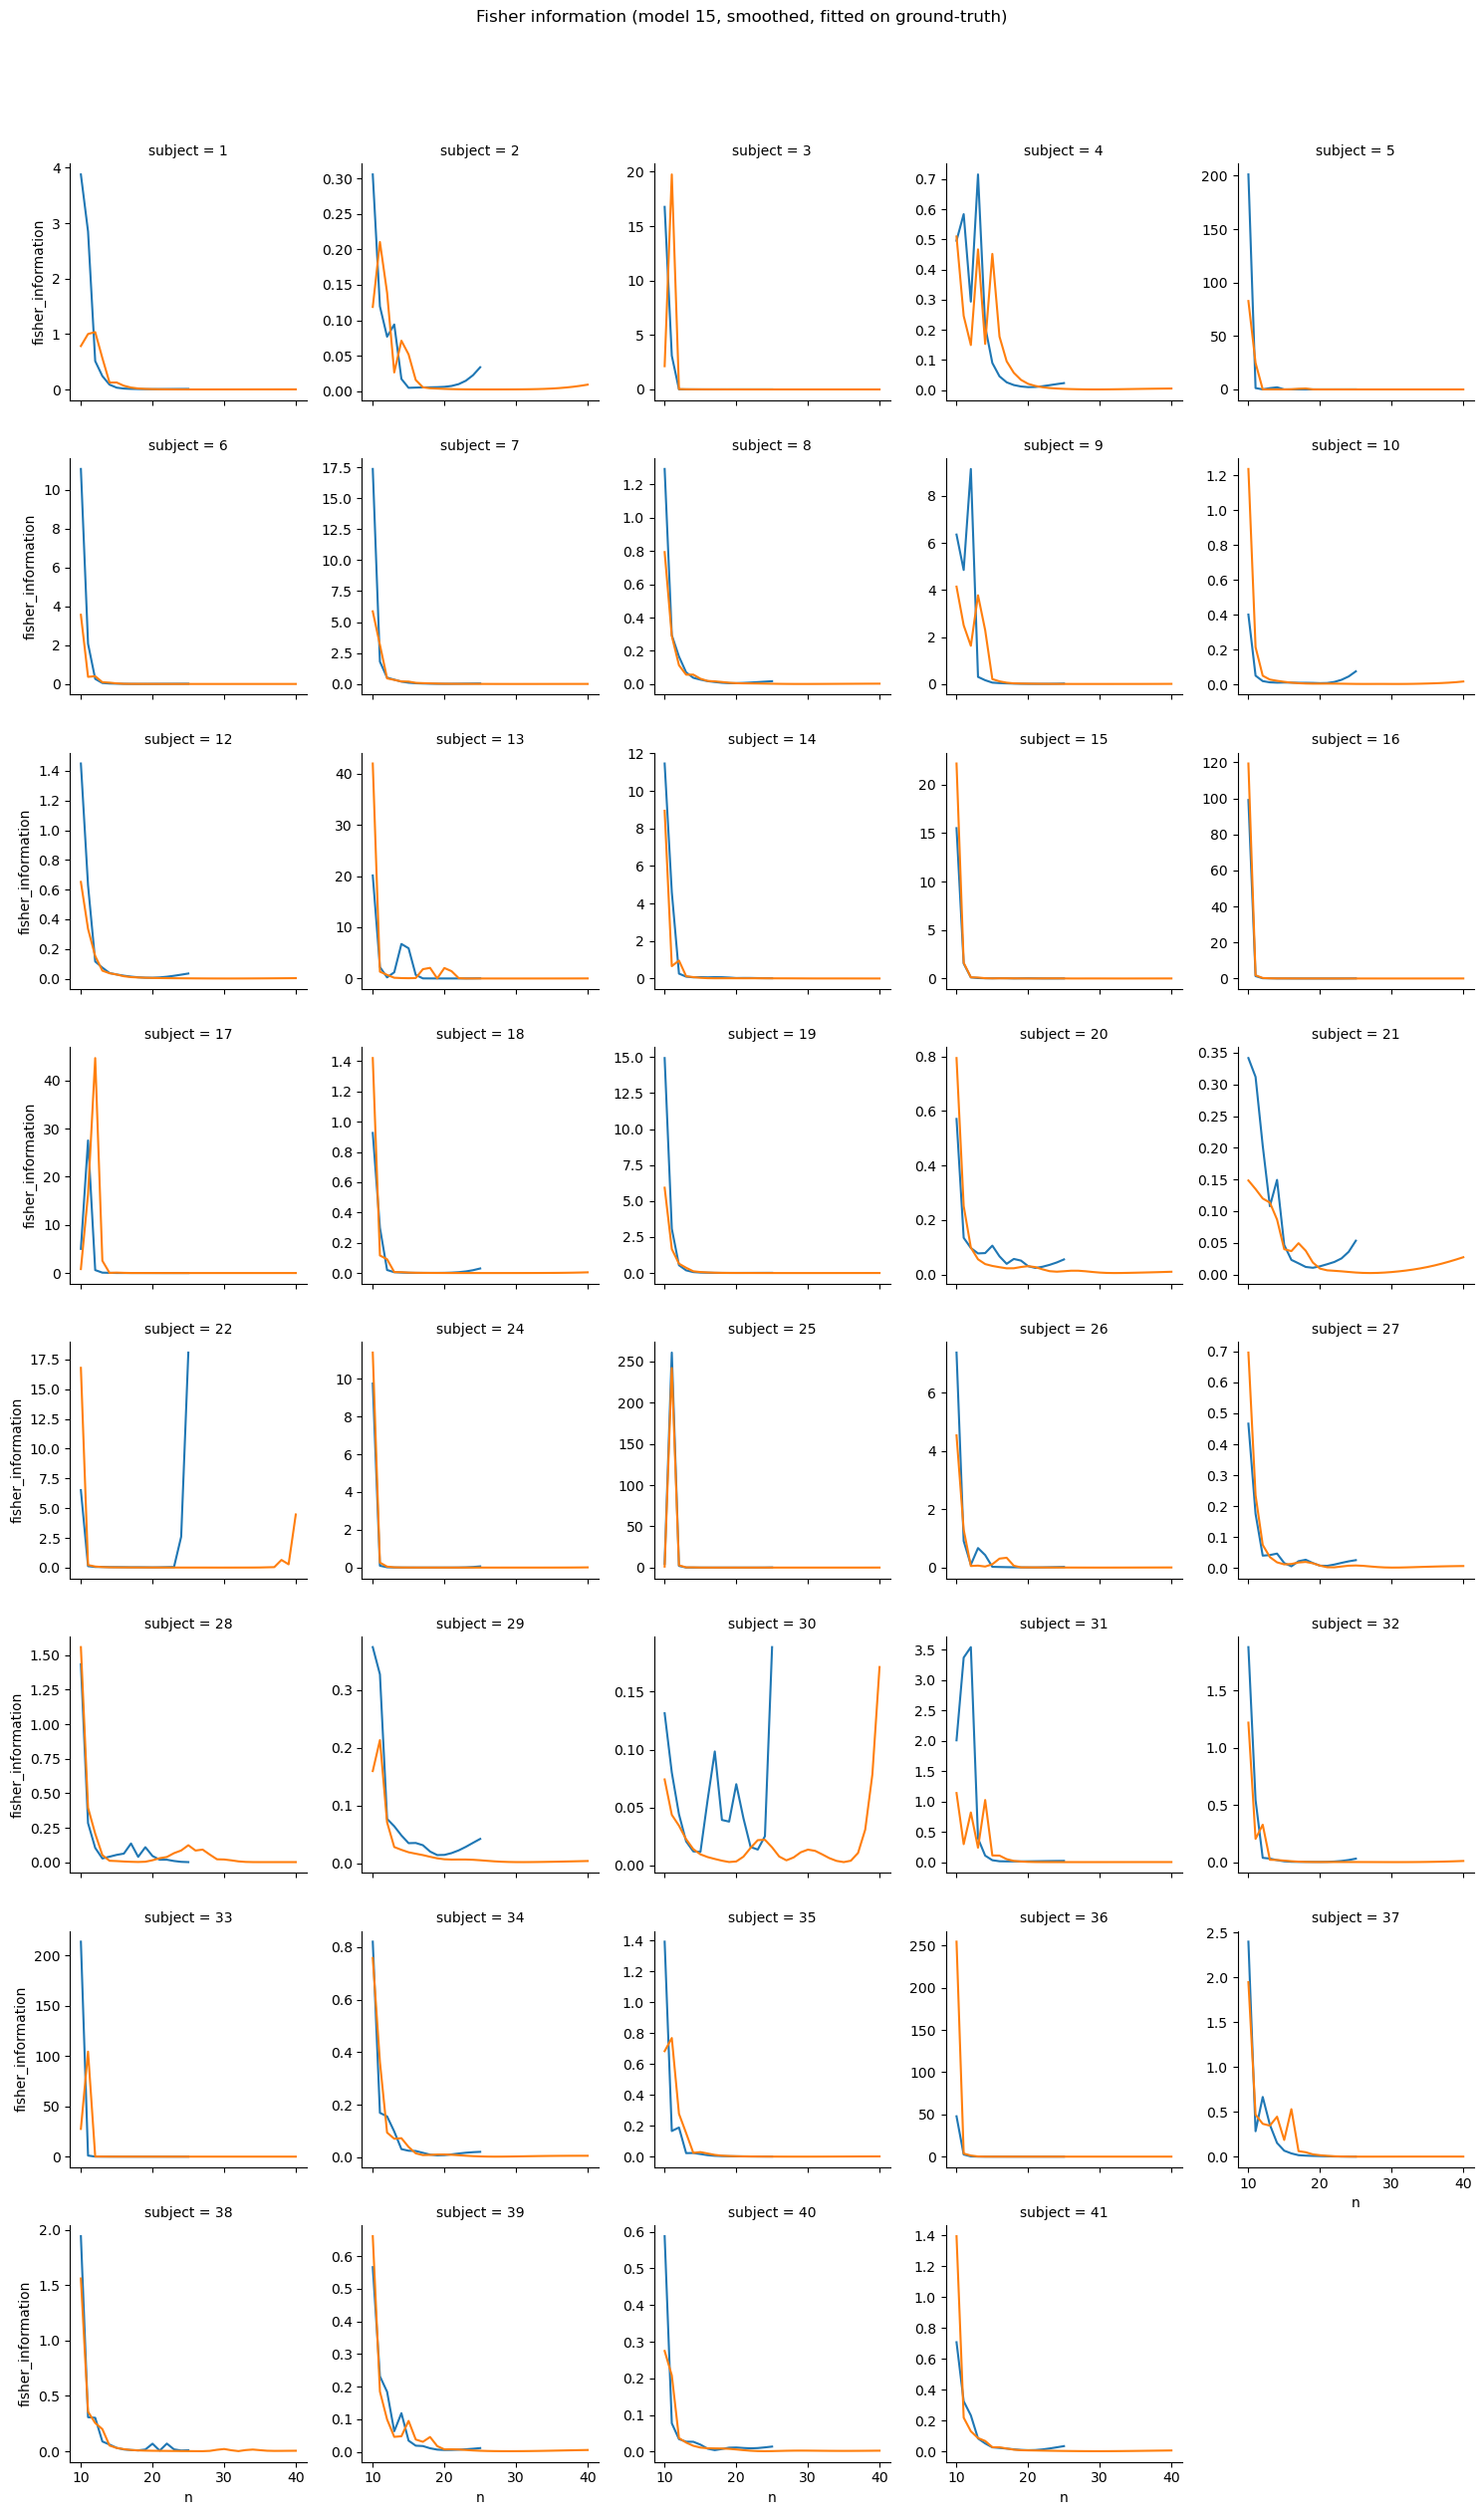

In [99]:
import seaborn as sns
g = sns.FacetGrid(fisher_information.reset_index(), col='subject', col_wrap=5, hue='condition', sharey=False)

g.map_dataframe(sns.lineplot, x='n', y='fisher_information')

g.fig.suptitle('Fisher information (model 15, smoothed, fitted on ground-truth)', y=1.05)

Text(0.5, 1.05, 'Log Fisher information (model 15, smoothed, fitted on ground-truth)')

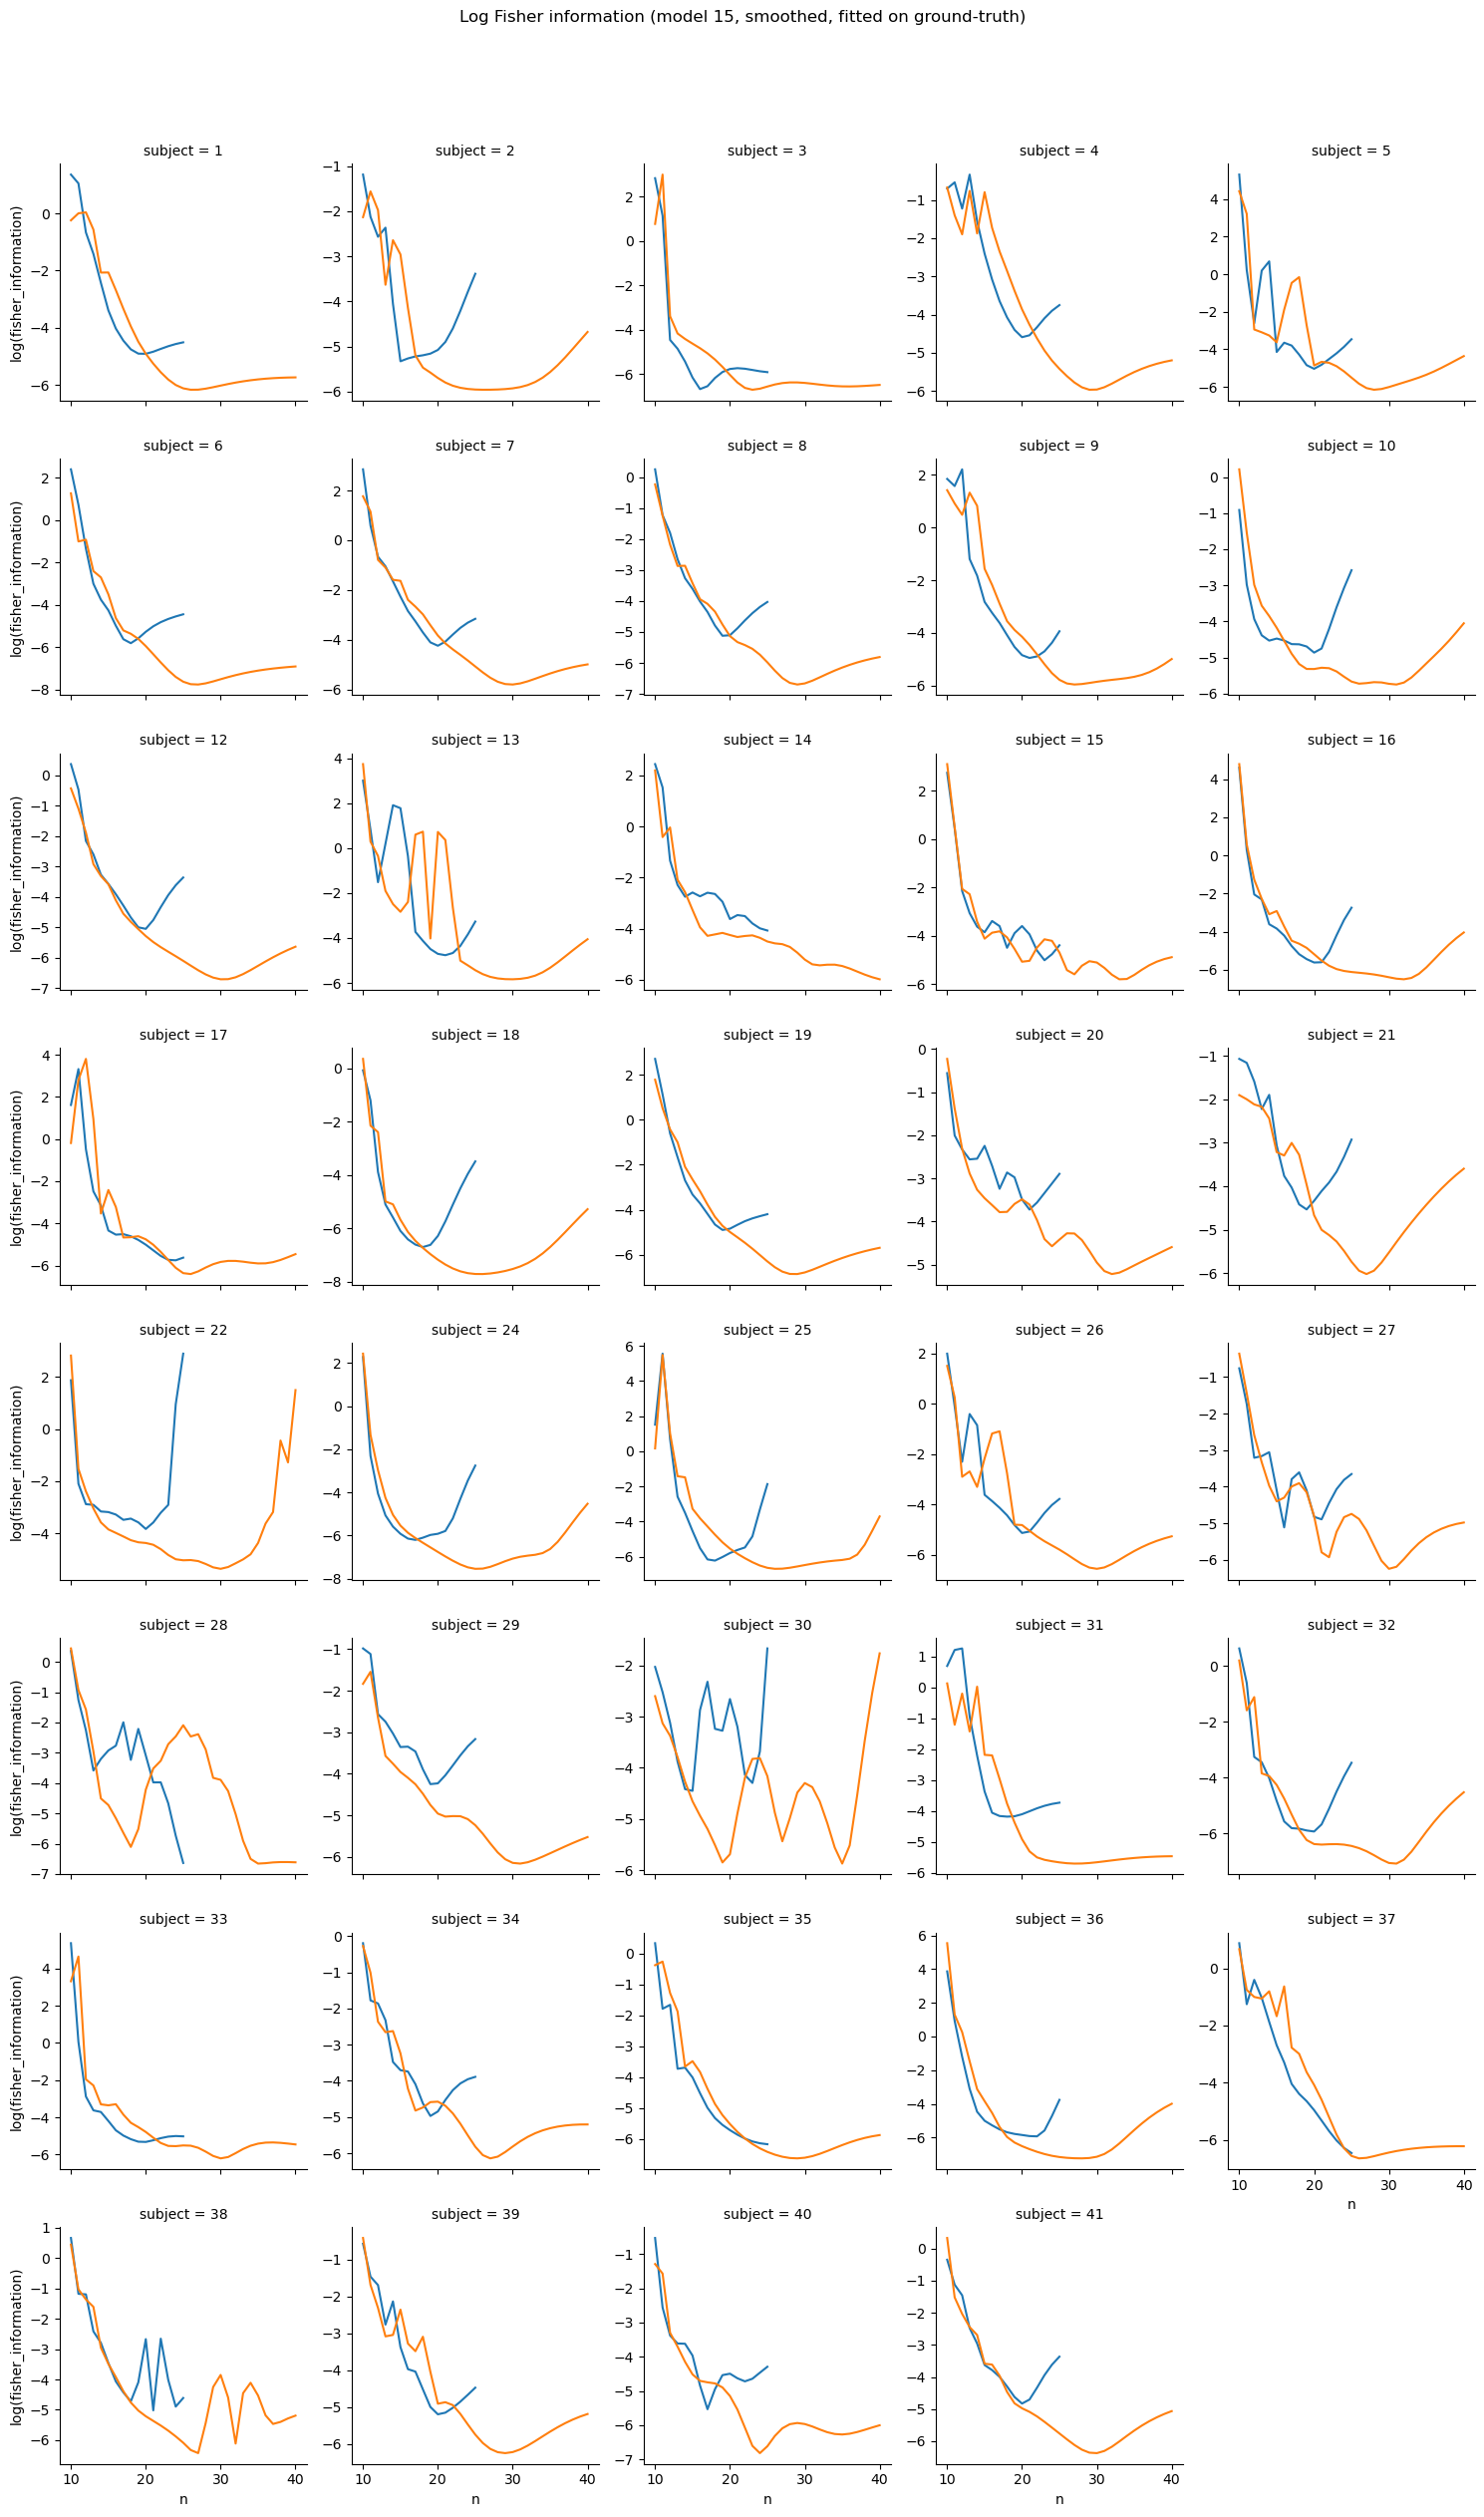

In [100]:
from scipy.stats import zscore
fisher_information['zscore(fisher_information)'] = fisher_information['fisher_information'].groupby('subject').apply(zscore).droplevel(0)

fisher_information['log(fisher_information)'] = np.log(fisher_information['fisher_information'])
g = sns.FacetGrid(fisher_information.reset_index(), col='subject', col_wrap=5, hue='condition', sharey=False)
g.map_dataframe(sns.lineplot, x='n', y='log(fisher_information)')

fisher_information['zscore(log(fisher_information))'] = fisher_information['log(fisher_information)'].groupby('subject').apply(zscore).droplevel(0)

g.fig.suptitle('Log Fisher information (model 15, smoothed, fitted on ground-truth)', y=1.05)

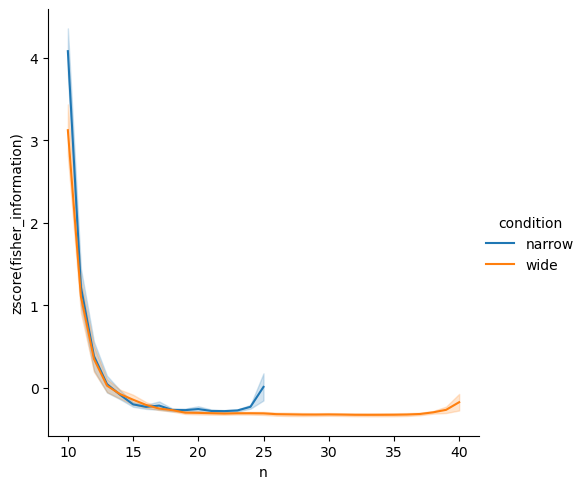

In [78]:
sns.relplot(x='n', y='zscore(fisher_information)', hue='condition', data=fisher_information.reset_index(), kind='line', errorbar='se')

Text(0.5, 1.05, 'Fisher information, group aggregrate (model 15, smoothed, fitted on ground-truth)')

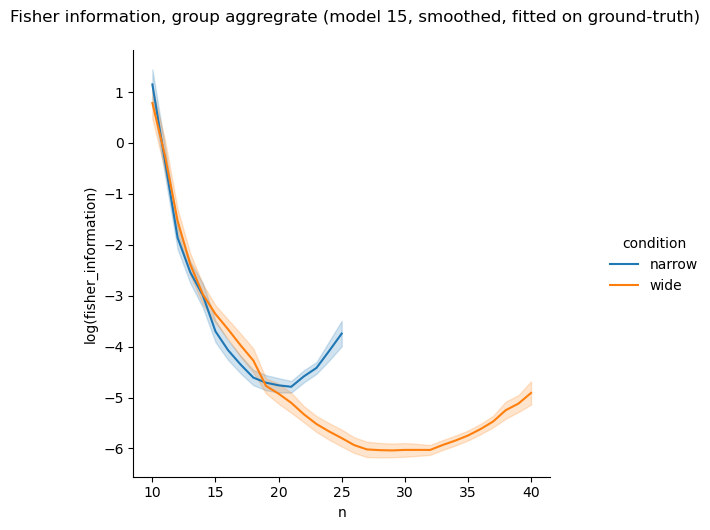

In [131]:
g = sns.relplot(x='n', y='log(fisher_information)', hue='condition', data=fisher_information.reset_index(), kind='line', errorbar='se')

g.fig.suptitle('Fisher information, group aggregrate (model 15, smoothed, fitted on ground-truth)', y=1.05)

Text(0.5, 1.05, 'Z-score of log Fisher information, group aggregrate (model 15, smoothed, fitted on ground-truth)')

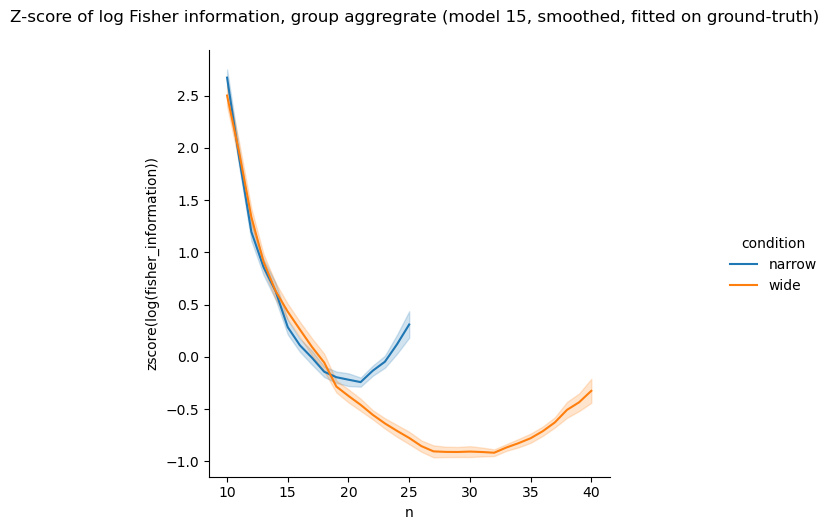

In [101]:
g = sns.relplot(x='n', y='zscore(log(fisher_information))', hue='condition', data=fisher_information.reset_index(), kind='line', errorbar='se')

g.fig.suptitle('Z-score of log Fisher information, group aggregrate (model 15, smoothed, fitted on ground-truth)', y=1.05)

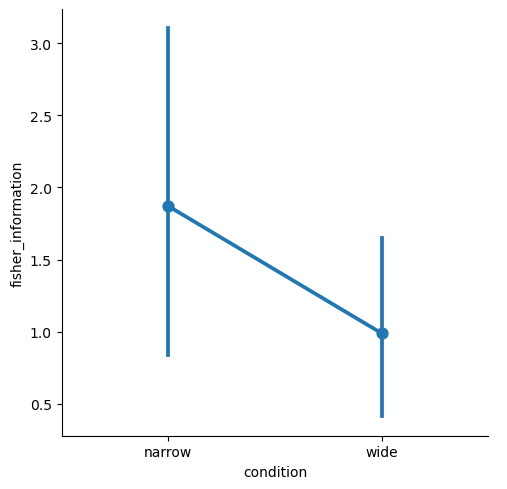

In [68]:
sns.catplot(x='condition', y='fisher_information', data=fisher_information.groupby(['condition', 'subject']).mean(), kind='point')

Text(0.5, 1.05, 'Average log Fisher information per unit n')

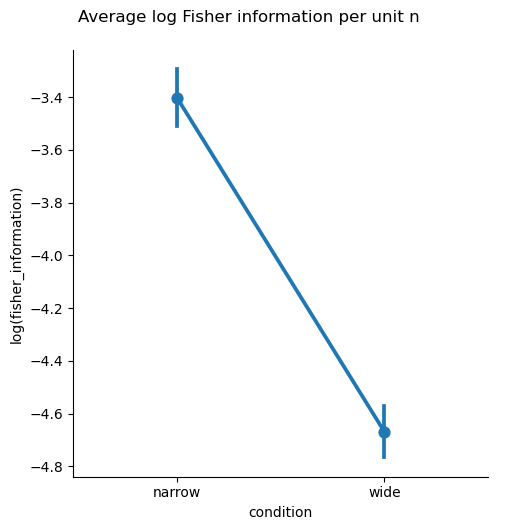

In [103]:
g = sns.catplot(x='condition', y='log(fisher_information)', data=fisher_information.groupby(['condition', 'subject']).mean(), kind='point', errorbar='se')

g.fig.suptitle('Average log Fisher information per unit n', y=1.05)

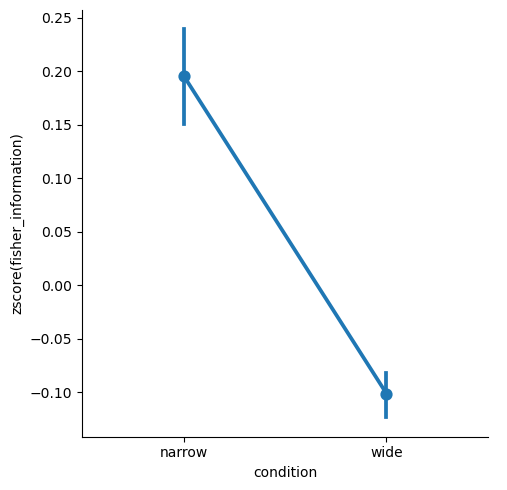

In [69]:
sns.catplot(x='condition', y='zscore(fisher_information)', data=fisher_information.groupby(['condition', 'subject']).mean(), kind='point')

In [1]:
import matplotlib.pyplot as plt
sns.scatterplot(data=fisher_information.groupby(['subject', 'condition'])['fisher_information'].sum().unstack(), x='narrow', y='wide')
plt.plot([0, 250], [0, 250])
plt.xlim(0, 100)
plt.ylim(0, 100)

NameError: name 'sns' is not defined

Text(0.5, 0.98, 'Sum of Fisher information over all n')

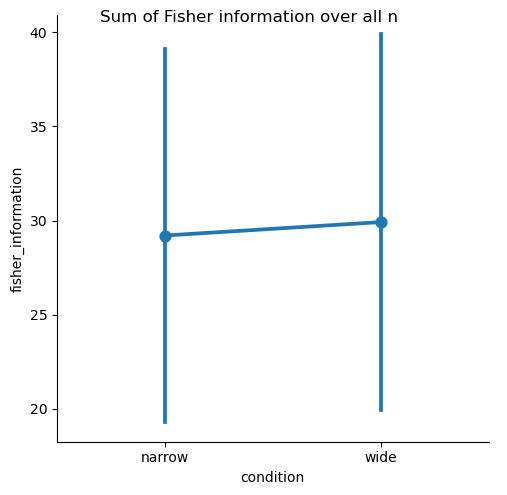

In [135]:
g = sns.catplot(x='condition', y='fisher_information', data=fisher_information.groupby(['condition', 'subject']).sum(), kind='point', errorbar='se')

g.fig.suptitle('Sum of Fisher information over all n')

In [137]:
fisher_information

Unnamed: 0     n  \
subject model_label fit_response smoothed                        
1       15          False        True     0            0  10.0   
                                          1            1  11.0   
                                          2            2  12.0   
                                          3            3  13.0   
                                          4            4  14.0   
...                                                  ...   ...   
41      15          False        True     42          42  36.0   
                                          43          43  37.0   
                                          44          44  38.0   
                                          45          45  39.0   
                                          46          46  40.0   

                                              fisher_information condition  \
subject model_label fit_response smoothed                                    
1       15          False        True     0             3.878444    narrow   
                                          1             2.850489    narrow   
                                          2             0.513108    narrow   
                                          3             0.242753    narrow   
                                          4             0.088248    narrow   
...                                                          ...       ...   
41      15          False        True     42            0.004024      wide   
                                          43            0.004616      wide   
                                          44            0.005206      wide   
                                          45            0.005779      wide   
                                          46            0.006324      wide   

                                              zscore(fisher_information)  \
subject model_label fit_response smoothed                                  
1       15          False        True     0                     5.114252   
                                          1                     3.667062   
                                          2                     0.376418   
                                          3                    -0.004197   
                                          4                    -0.221716   
...                                                                  ...   
41      15          False        True     42                   -0.327439   
                                          43                   -0.324830   
                                          44                   -0.322227   
                                          45                   -0.319698   
                                          46                   -0.317298   

                                              log(fisher_information)  \
subject model_label fit_response smoothed                               
1       15          False        True     0                  1.355434   
                                          1                  1.047491   
                                          2                 -0.667268   
                                          3                 -1.415709   
                                          4                 -2.427606   
...                                                               ...   
41      15          False        True     42                -5.515424   
                                          43                -5.378284   
                                          44                -5.257921   
                                          45                -5.153440   
                                          46                -5.063455   

                                              zscore(log(fisher_information))  \
subject model_label fit_response smoothed                                       
1       15          False        True     0                          2.

Text(0.5, 0.98, 'Sum of Fisher information over all n')

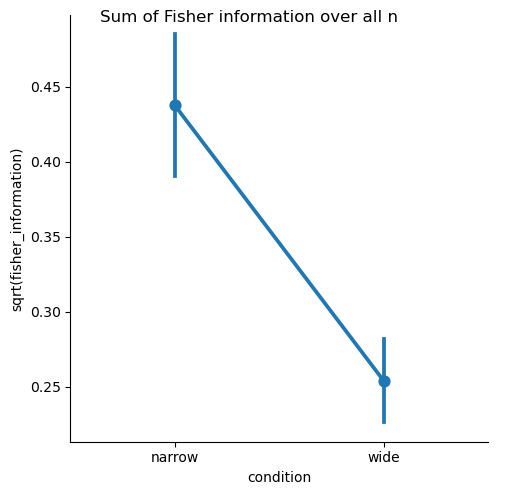

In [139]:
fisher_information['sqrt(fisher_information)'] = np.sqrt(fisher_information['fisher_information'])
g = sns.catplot(x='condition', y='sqrt(fisher_information)', data=fisher_information.groupby(['condition', 'subject']).mean(), kind='point', errorbar='se')

g.fig.suptitle('Sum of Fisher information over all n')

Text(0.5, 0.98, 'Sum of Fisher information over all n')

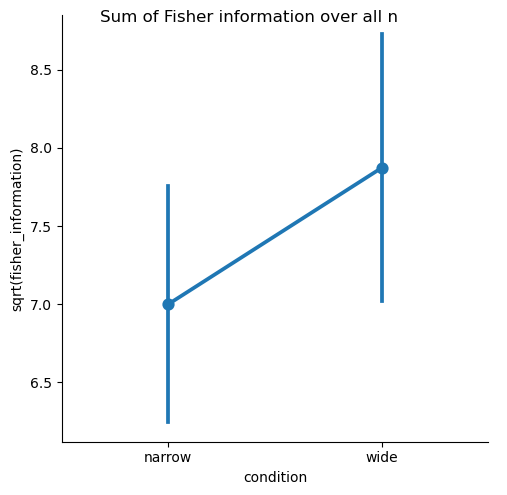

In [138]:
fisher_information['sqrt(fisher_information)'] = np.sqrt(fisher_information['fisher_information'])
g = sns.catplot(x='condition', y='sqrt(fisher_information)', data=fisher_information.groupby(['condition', 'subject']).sum(), kind='point', errorbar='se')

g.fig.suptitle('Sum of Fisher information over all n')

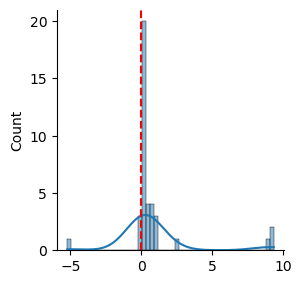

In [130]:
g = sns.FacetGrid(fisher_information.groupby(['subject', 'condition'])['log(fisher_information)'].mean().to_frame('Average Fisher information').reset_index(),
                  hue='condition', )

# g.map(sns.histplot, 'Average Fisher information', bins=20, kde=True)

# g.add_legend()

tmp = fisher_information.groupby(['subject', 'condition'])['fisher_information'].mean().unstack('condition')

sns.histplot(tmp['narrow'] - tmp['wide'], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')

In [2]:
subject_id = 39
model_label = 15
roi = 'NPCr'
sub = Subject(subject_id)
smoothed=True



In [7]:
pars

,mu_narrow,delta_wide,lower_bound_range,baseline,sd_narrow,sd_wide_scale,amplitude
0,13.856637,2.0,10.0,-0.628670,0.685640,1.206971,0.498708
1,9.999081,2.0,10.0,-0.139407,0.021611,1.206971,0.352546
2,9.999626,2.0,10.0,-0.036238,0.019902,1.206971,0.320201
3,15.888694,2.0,10.0,-0.707054,0.687966,1.206971,0.616685
4,16.301577,2.0,10.0,-0.545473,0.531605,1.206971,0.535949
...,...,...,...,...,...,...,...
892,9.995830,2.0,10.0,-0.286171,0.139701,1.206971,0.531214
893,9.780255,2.0,10.0,-0.125582,0.127075,1.206971,0.390065
894,8.367441,2.0,10.0,-0.311396,0.421756,1.206971,0.452693
895,9.293250,2.0,10.0,-0.230689,0.289935,1.206971,0.236809


In [4]:
paradigm = get_paradigm(sub)

data = sub.get_single_trial_estimates(session=None, smoothed=smoothed)
masker = sub.get_volume_mask(roi=roi, epi_space=True, return_masker=True)
data = pd.DataFrame(masker.fit_transform(data), index=paradigm.index).astype(np.float32)

In [5]:
model = get_model(15)
pars = sub.get_prf_parameters_volume2(model_label, smoothed=True, roi='NPCr')
pars[('alpha',0 )] = 1e-6
pars[('lower_bound',0 )] = 10.
pars[('sd_scale', 0)] = pars[('sd', 'wide')] / pars[('sd', 'narrow')]
print(model.parameter_labels)

p = pars[[('mu', 'narrow'), ('delta_wide', 'narrow'), ('lower_bound', 0), ('baseline', 'narrow'), ('sd', 'narrow'), ('sd_scale', 0), ('amplitude', 'narrow')]]

p.columns = model.parameter_labels

['mu_narrow', 'delta_wide', 'lower_bound_range', 'baseline', 'sd_narrow', 'sd_wide_scale', 'amplitude']


In [184]:
mask = pars['cvr2'].squeeze() > 0.0

data = data.loc[:, mask]
p = p.loc[mask, :]

In [185]:
pred = model.predict(paradigm, p)

In [186]:
r2 = get_rsq(data, pred)

r2.sort_values()

603    0.006872
334    0.008687
445    0.008693
380    0.009750
339    0.010163
         ...   
862    0.143750
782    0.152233
765    0.156894
764    0.160236
766    0.181575
Name: r2, Length: 490, dtype: float32

In [187]:
import matplotlib.pyplot as plt
# plt.scatter(data[243], pred[243])

In [188]:
from braincoder.optimize import ResidualFitter

In [189]:
resid_fitter = ResidualFitter(model, data, paradigm, p)

stimulus_range = np.concatenate((np.arange(10, 41, 1)[:, np.newaxis], np.ones(31)[:, np.newaxis]), axis=1)
model.init_pseudoWWT(stimulus_range, p)

<tf.Tensor: shape=(490, 490), dtype=float32, numpy=
array([[11.021234 ,  6.071082 ,  5.6588593, ...,  4.2524395,  3.9937596,
         1.9334402],
       [ 6.071082 ,  3.4449444,  3.2223449, ...,  2.5847526,  2.3540819,
         1.2027214],
       [ 5.6588593,  3.2223449,  3.0273616, ...,  2.4366932,  2.2440038,
         1.1373981],
       ...,
       [ 4.2524395,  2.5847526,  2.4366932, ...,  2.2540975,  1.9238243,
         1.100944 ],
       [ 3.9937596,  2.3540819,  2.2440038, ...,  1.9238243,  1.7880319,
         0.9173077],
       [ 1.9334402,  1.2027214,  1.1373981, ...,  1.100944 ,  0.9173077,
         0.5510058]], dtype=float32)>

In [190]:
omega, dof = resid_fitter.fit()

init_tau: 0.33875980973243713, 1.6244086027145386
USING A PSEUDO-WWT!
WWT max: 57.68223190307617


  0%|          | 0/1000 [00:00<?, ?it/s]

In [191]:
narrow_stimuli = np.concatenate((np.arange(10, 26, 1)[:, np.newaxis], np.zeros(16)[:, np.newaxis]), axis=1).astype(np.float32)
wide_stimuli = np.concatenate((np.arange(10, 41, 1)[:, np.newaxis], np.ones(31)[:, np.newaxis]), axis=1).astype(np.float32)

stimuli = np.concatenate((narrow_stimuli, wide_stimuli), axis=0).astype(np.float32)


fisher_information = model.get_fisher_information(stimuli, omega)

In [192]:
fisher_information = fisher_information.to_frame('fisher_information')

fisher_information.index.names = ['n', 'wide']

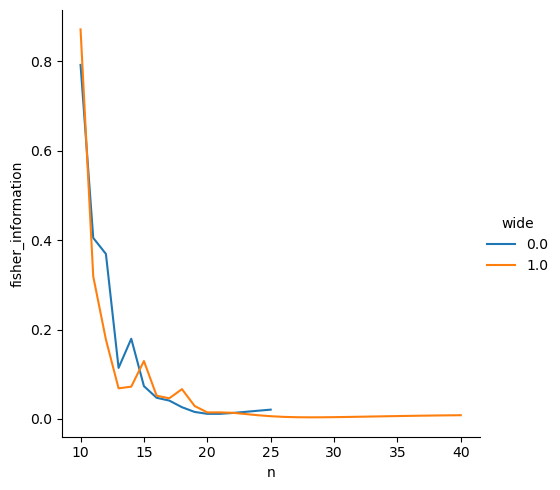

In [193]:
import seaborn as sns
sns.relplot(data=fisher_information.reset_index(), x='n', y='fisher_information', hue='wide', kind='line')

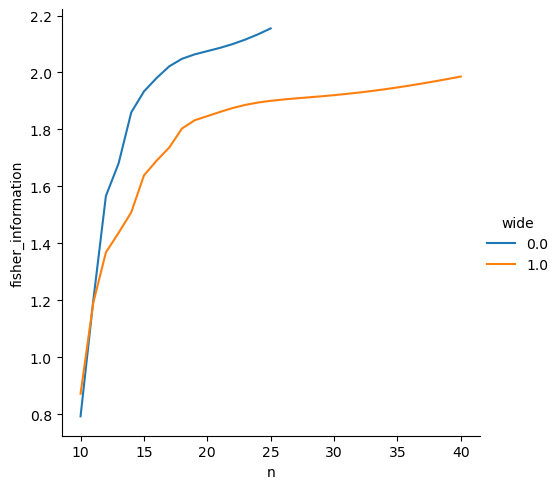

In [194]:
sns.relplot(x='n', y='fisher_information', data=fisher_information.groupby('wide').cumsum().reset_index(), hue='wide', kind='line')

In [110]:
model.get_WWT()

<tf.Tensor: shape=(216, 216), dtype=float32, numpy=
array([[0.0706308 , 0.11813539, 0.1733879 , ..., 0.07901098, 0.07526699,
        0.09219183],
       [0.11813539, 0.27177677, 0.39509737, ..., 0.05255144, 0.0270076 ,
        0.08334075],
       [0.1733879 , 0.39509737, 0.7754769 , ..., 0.24739559, 0.30845934,
        0.27444935],
       ...,
       [0.07901098, 0.05255144, 0.24739559, ..., 0.4218356 , 0.56722414,
        0.40382838],
       [0.07526699, 0.0270076 , 0.30845934, ..., 0.56722414, 0.7864185 ,
        0.5338882 ],
       [0.09219183, 0.08334075, 0.27444935, ..., 0.40382838, 0.5338882 ,
        0.3915713 ]], dtype=float32)>

In [107]:
stimulus_range.shape

(31, 2, 1)

In [22]:
model.parameter_labels

['mu_narrow',
 'alpha',
 'delta_wide',
 'lower_bound_range',
 'sd_narrow',
 'sd_wide',
 'amplitude',
 'baseline']

In [ ]:
paradigm = sub.get_behavioral_data

In [16]:
pars

mu                   sd           delta_wide      amplitude  \
        narrow       wide    narrow      wide     narrow wide    narrow   
0     8.398018   8.398018  0.198380  0.256543        2.0  2.0  0.450759   
1     9.130525   9.130525  0.227340  0.293993        2.0  2.0  0.207075   
2     5.390759   5.390759  0.485376  0.627682        2.0  2.0  0.135860   
3     7.849939   7.849939  0.544100  0.703622        2.0  2.0  0.170374   
4     8.565746   8.565746  0.236185  0.305431        2.0  2.0  0.390932   
..         ...        ...       ...       ...        ...  ...       ...   
766  14.350670  18.701340  1.330357  1.720398        2.0  2.0  0.789523   
767   6.583015   6.583015  0.255661  0.330617        2.0  2.0  0.389053   
768  10.000820  10.001640  1.752789  2.266681        2.0  2.0  0.857362   
769  46.978001  83.956001  0.366954  0.474539        2.0  2.0  0.251643   
770  10.465875  10.931749  0.048025  0.062105        2.0  2.0  0.283052   

               baseline                  r2      cvr2  
         wide    narrow      wide       NaN       NaN  
0    0.450759 -0.115189 -0.115189  0.007734 -0.025105  
1    0.207075 -0.520291 -0.520291  0.003757 -0.018064  
2    0.135860 -0.494032 -0.494032  0.000699 -0.022903  
3    0.170374 -0.337492 -0.337492  0.004310 -0.013713  
4    0.390932 -0.115462 -0.115462  0.007227 -0.015110  
..        ...       ...       ...       ...       ...  
766  0.789523 -0.414891 -0.414891  0.004719 -0.010240  
767  0.389053 -0.013281 -0.013281  0.009863 -0.015661  
768  0.857362 -0.432052 -0.432052  0.006105 -0.015273  
769  0.251643 -0.068113 -0.068113  0.003480 -0.018117  
770  0.283052  0.169557  0.169557  0.018948 -0.013795  

[771 rows x 12 columns]

In [17]:
pars.loc[pars[('cvr2', np.nan)] > 0.0]

mu                   sd           delta_wide      amplitude  \
        narrow       wide    narrow      wide     narrow wide    narrow   
10   11.710655  13.421310  0.116271  0.150360        2.0  2.0  0.696842   
13   11.601078  13.202156  0.118684  0.153481        2.0  2.0  0.657865   
14   11.704513  13.409025  0.104617  0.135289        2.0  2.0  0.600405   
16   11.352913  12.705826  0.129535  0.167513        2.0  2.0  0.463029   
17   11.471303  12.942606  0.107727  0.139311        2.0  2.0  0.579470   
..         ...        ...       ...       ...        ...  ...       ...   
426   7.873641   7.873641  1.058465  1.368791        2.0  2.0  0.652197   
427  10.817915  11.635830  1.083293  1.400898        2.0  2.0  0.742884   
604  14.395726  18.791452  0.821439  1.062273        2.0  2.0  0.705414   
672  10.540886  11.081772  0.039005  0.050440        2.0  2.0  0.349664   
698  10.565760  11.131519  0.041722  0.053955        2.0  2.0  0.320470   

               baseline                  r2      cvr2  
         wide    narrow      wide       NaN       NaN  
10   0.696842 -0.462948 -0.462948  0.044672  0.016193  
13   0.657865 -0.359827 -0.359827  0.049339  0.019102  
14   0.600405 -0.617109 -0.617109  0.035325  0.004319  
16   0.463029 -0.285730 -0.285730  0.036629  0.012011  
17   0.579470 -0.430497 -0.430497  0.045194  0.011692  
..        ...       ...       ...       ...       ...  
426  0.652197  0.016113  0.016113  0.040094  0.012497  
427  0.742884 -0.044238 -0.044238  0.030029  0.009460  
604  0.705414 -0.611198 -0.611198  0.009886  0.001118  
672  0.349664  0.078310  0.078310  0.022881  0.008676  
698  0.320470  0.031386  0.031386  0.027252  0.013880  

[90 rows x 12 columns]

In [5]:
pars = sub.get_prf_parameters_volume2?

Signature:
sub.get_prf_parameters_volume2(
    model_label,
    smoothed=True,
    roi=None,
    response_fit=False,
    return_image=False,
)
Docstring: <no docstring>
File:      ~/git/neural_priors/neural_priors/utils/data.py
Type:      method